In [1]:
import pandas as pd
import feature_engineering_helper as hf
import pickle


In [2]:

### change this to 1 for quick test, 0 for full run
quick_test = 1
### change this to 1 for quick test, 0 for full run


if quick_test == 1:
    n_features_to_select=20
    num_feat_binary_interaction = 20
    step=50
    print("Quick test mode")
else:
    n_features_to_select=1
    step=5
    num_feat_binary_interaction = 20
    print("Full run mode")



Quick test mode


In [3]:
data_prefix = '../data_curation/processed_data/'

if quick_test == 1:
    df_all_feature = pd.read_parquet(data_prefix + 'data_with_all_features.parquet').head(500)
else:
    df_all_feature = pd.read_parquet(data_prefix + 'data_with_all_features.parquet')

df_all_feature

,MACCS_0,MACCS_1,MACCS_10,MACCS_100,MACCS_101,MACCS_102,MACCS_103,MACCS_104,MACCS_105,MACCS_106,...,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,Ro5,SMILES,Type
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0.346320,1,ON=Cc1cscc1,Train
1,0,0,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0.742933,1,O=C1CC[C@]2(C(=C1)CC[C@@H]1[C@@H]2[C@H](O)C[C@...,Train
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0.336491,1,[O-][n+]1ccccc1,Train
3,0,0,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0.470129,1,OC1CCC2(C(C1)CC=C1C2CCC2(C1CCC2C(CCC(C(C)C)C)C...,Train
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.635067,1,CC(=O)c1ccc(cc1)Br,Train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0.290981,1,ONC(c1ccc(cc1)N)C/C(=N/O)/c1ccccc1,Train
496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.636026,1,COc1cccc(c1)P(c1cccc(c1)OC)c1cccc(c1)OC,Train
497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,17,0,0.163506,1,CCCCCCCCCCCCCCCCCCCCCC(=O)OC,Train
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0.584759,1,CCCCCCc1ccc(cc1)c1ccccc1,Train


In [4]:
data_with_features_train = df_all_feature[df_all_feature['Type'] == 'Train']
print(data_with_features_train.shape)

data_with_features_train.describe()

(500, 379)


,MACCS_0,MACCS_1,MACCS_10,MACCS_100,MACCS_101,MACCS_102,MACCS_103,MACCS_104,MACCS_105,MACCS_106,...,RDKit_fr_sulfone,RDKit_fr_term_acetylene,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,Ro5
count,500.0,500.0,500.0,500.00000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.00000,500.0,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.0,0.0,0.0,0.11400,0.268000,0.188000,0.158000,0.14600,0.282000,0.172000,...,0.010000,0.004000,0.002000,0.02000,0.0,0.014000,0.486000,0.016000,0.577408,0.976000
std,0.0,0.0,0.0,0.31813,0.443361,0.391103,0.365106,0.35346,0.450424,0.377758,...,0.099598,0.063182,0.044721,0.14014,0.0,0.117608,2.756265,0.154245,0.171516,0.153202
min,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.038349,0.000000
25%,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.482244,1.000000
50%,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.596856,1.000000
75%,0.0,0.0,0.0,0.00000,1.000000,0.000000,0.000000,0.00000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.698684,1.000000
max,0.0,0.0,0.0,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.00000,0.0,1.000000,39.000000,2.000000,0.942098,1.000000


In [5]:
def feature_engineering_workflow(data_type):

    tolerance = 0.01

    # Extract all feature columns
    all_feature_cols = data_with_features_train.drop(columns=['SMILES', 'MP', 'Type', 'Ro5'], axis=1).columns.tolist()
    print(f"Total number of features: {len(all_feature_cols)}")

    # Subset data based on data_type
    if data_type == 'Ro5':
        data = data_with_features_train[data_with_features_train['Ro5'] == 1].reset_index(drop=True)
    if data_type == 'bRo5':
        data = data_with_features_train[data_with_features_train['Ro5'] == 0].reset_index(drop=True)
    print(f"Processing {data_type} dataset with shape: {data.shape}")
    print()

    # Standardize features
    df_X_scaled = hf.standardize_features(data = data, all_feature_cols=all_feature_cols, scaler_path= data_prefix + f'scaler_{data_type}.pkl', fit=True) 
    print()


    # Reduce features by variance threshold
    df_X_variance = hf.reduce_features_by_variance(df_X_scaled, variance_threshold=0.01)
    print()

    def RFE_workflow(df_X_variance, round):
        print()
        print(f'RFE feature selection: Round {round}:')
        # Reduce features by RFE
        RFE_results = hf.reduce_features_by_RFE(df_X_variance, data['MP'], tolerance = tolerance, n_features_to_select=n_features_to_select, step=step, metric='rmse', cv_strategy=None)
        print()

        # Plot RFE results
        hf.RFE_plot(RFE_results, tolerance)
        # Pickle save the RFE_results
        with open(data_prefix + f'RFE_results_{data_type}_{round}.pkl', 'wb') as f:
            pickle.dump(RFE_results, f)

        df_X_RFE = df_X_variance[RFE_results['best_features']]

        return df_X_RFE, RFE_results

    # First round of RFE
    df_X_RFE, RFE_results_1 = RFE_workflow(df_X_variance, 1)

    # Feature binary interactions
    df_X_interaction = hf.feature_interaction(df_X_RFE, top_n_features=num_feat_binary_interaction)

    # Second round of RFE
    df_X_final, RFE_results_2 = RFE_workflow(df_X_interaction, 2)


    

    return df_X_scaled, df_X_variance, RFE_results_1, df_X_RFE, RFE_results_2, df_X_final

Total number of features: 375
Processing Ro5 dataset with shape: (488, 379)

✓ Scaler saved to: ../data_curation/processed_data/scaler_Ro5.pkl
✓ Standardization complete. Shape: (488, 375)

Original features: 375
Removed features: 24
Remaining features: 351


RFE feature selection: Round 1:


RFE Feature Selection:  14%|█▍        | 1/7 iteration

Iteration 0/7 | Features: 301 | RMSE: 50.9181 ± 4.8852 | Removed: [MACCS_22, MACCS_23, MACCS_24, MACCS_25, MACCS_28, MACCS_29, MACCS_30, MACCS_31, MACCS_32, MACCS_33, MACCS_37, MACCS_38, MACCS_40, MACCS_44, MACCS_49, MACCS_51, MACCS_52, MACCS_54, MACCS_55, MACCS_56, MACCS_58, MACCS_60, MACCS_61, MACCS_63, MACCS_67, MACCS_68, MACCS_70, MACCS_71, MACCS_76, RDKit_MaxEStateIndex, RDKit_NumAromaticRings, RDKit_NumSaturatedHeterocycles, RDKit_NumSaturatedRings, RDKit_fr_NH2, RDKit_fr_N_O, RDKit_fr_azo, RDKit_fr_barbitur, RDKit_fr_benzene, RDKit_fr_epoxide, RDKit_fr_ether, RDKit_fr_guanido, RDKit_fr_imidazole, RDKit_fr_imide, RDKit_fr_isothiocyan, RDKit_fr_ketone, RDKit_fr_lactam, RDKit_fr_oxime, RDKit_fr_phenol_noOrthoHbond, RDKit_fr_phos_acid, RDKit_fr_urea]


RFE Feature Selection: 100%|██████████| 7/7 iteration



Global best RMSE: 47.1709
Threshold (1.0% tolerance): 47.6426

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 20
  Selected RMSE: 47.1709
  Best features (Top 5): ['RDKit_NHOHCount', 'RDKit_fr_Ar_COO', 'RDKit_fr_NH1', 'MACCS_43', 'MACCS_120']



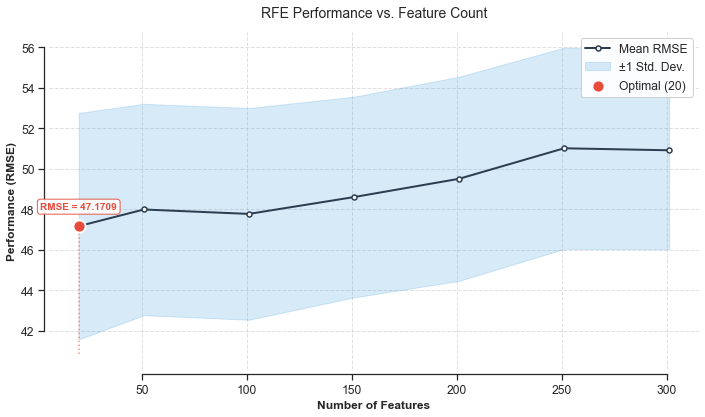

  Optimal Feature Set: 20 features
  Best RMSE: 47.1709
Selecting top 20 features for interaction generation out of 20 available.
Generating 190 interaction features from 20 features...

RFE feature selection: Round 2:


RFE Feature Selection:  25%|██▌       | 1/4 iteration

Iteration 0/4 | Features: 160 | RMSE: 47.8688 ± 6.2633 | Removed: [RDKit_fr_Ar_COO, RDKit_fr_NH1, MACCS_120, RDKit_fr_methoxy, RDKit_EState_VSA10, RDKit_fr_C_O_noCOO, MACCS_59, MACCS_120 X MACCS_131, MACCS_120 X MACCS_59, MACCS_120 X RDKit_NHOHCount, MACCS_120 X RDKit_fr_Ar_COO, MACCS_120 X RDKit_fr_NH1, MACCS_120 X RDKit_fr_methoxy, MACCS_126 X MACCS_43, MACCS_126 X MACCS_59, MACCS_126 X RDKit_NumRotatableBonds, MACCS_126 X RDKit_fr_NH1, MACCS_126 X RDKit_fr_methoxy, MACCS_131 X MACCS_43, MACCS_131 X MACCS_59, MACCS_131 X RDKit_PEOE_VSA14, MACCS_131 X RDKit_SlogP_VSA2, MACCS_131 X RDKit_fr_Ar_COO, MACCS_131 X RDKit_fr_NH1, MACCS_43 X MACCS_59, MACCS_43 X RDKit_EState_VSA2, MACCS_43 X RDKit_NHOHCount, MACCS_43 X RDKit_NumHeteroatoms, MACCS_43 X RDKit_RingCount, MACCS_43 X RDKit_fr_C_O_noCOO, MACCS_43 X RDKit_fr_NH1, MACCS_43 X RDKit_fr_methoxy, MACCS_59 X RDKit_NHOHCount, MACCS_59 X RDKit_NumRotatableBonds, MACCS_59 X RDKit_RingCount, MACCS_59 X RDKit_fr_Ar_COO, MACCS_59 X RDKit_fr_C_O

RFE Feature Selection: 100%|██████████| 4/4 iteration



Global best RMSE: 47.8688
Threshold (1.0% tolerance): 48.3474

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 60
  Selected RMSE: 47.9329
  Best features (Top 5): ['MACCS_131 X RDKit_NHOHCount', 'RDKit_BertzCT X RDKit_fr_Ar_COO', 'MACCS_43 X RDKit_fr_Ar_COO', 'MACCS_131 X RDKit_fr_C_O_noCOO', 'MACCS_126 X RDKit_fr_C_O_noCOO']



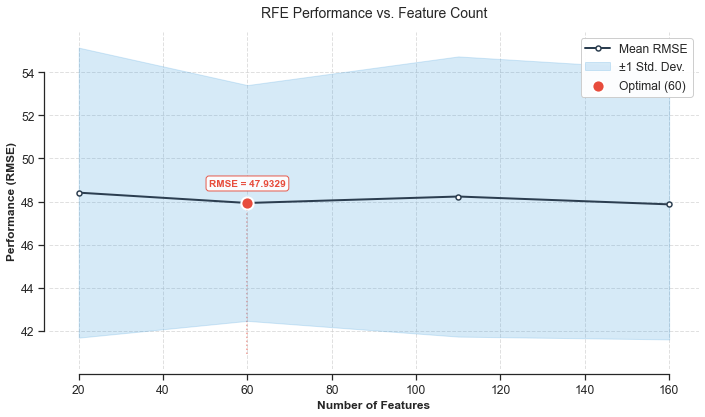

  Optimal Feature Set: 60 features
  Best RMSE: 47.9329


In [6]:
df_Ro5_X_scaled, df_Ro5_X_variance, RFE_results_Ro5_1, df_Ro5_X_RFE, RFE_results_Ro5_2, df_Ro5_X_final = feature_engineering_workflow('Ro5')

Total number of features: 375
Processing bRo5 dataset with shape: (12, 379)

✓ Scaler saved to: ../data_curation/processed_data/scaler_bRo5.pkl
✓ Standardization complete. Shape: (12, 375)

Original features: 375
Removed features: 114
Remaining features: 261


RFE feature selection: Round 1:


RFE Feature Selection:  20%|██        | 1/5 iteration

Iteration 0/5 | Features: 211 | RMSE: 137.7524 ± 78.2366 | Removed: [RDKit_Chi0v, RDKit_Chi1, RDKit_Chi1n, RDKit_Chi1v, RDKit_Chi2n, RDKit_Chi2v, RDKit_Chi3n, RDKit_Chi3v, RDKit_Chi4n, RDKit_Chi4v, RDKit_EState_VSA1, RDKit_EState_VSA10, RDKit_EState_VSA11, RDKit_EState_VSA7, RDKit_EState_VSA9, RDKit_ExactMolWt, RDKit_FpDensityMorgan2, RDKit_FpDensityMorgan3, RDKit_FractionCSP3, RDKit_MaxAbsPartialCharge, RDKit_MaxEStateIndex, RDKit_MinAbsEStateIndex, RDKit_MinAbsPartialCharge, RDKit_MinEStateIndex, RDKit_MinPartialCharge, RDKit_MolLogP, RDKit_MolMR, RDKit_MolWt, RDKit_NHOHCount, RDKit_NOCount, RDKit_NumAliphaticCarbocycles, RDKit_NumAliphaticHeterocycles, RDKit_NumAromaticCarbocycles, RDKit_NumAromaticHeterocycles, RDKit_NumAromaticRings, RDKit_NumHAcceptors, RDKit_NumHDonors, RDKit_NumHeteroatoms, RDKit_NumRotatableBonds, RDKit_NumSaturatedCarbocycles, RDKit_NumSaturatedHeterocycles, RDKit_NumValenceElectrons, RDKit_PEOE_VSA10, RDKit_PEOE_VSA11, RDKit_PEOE_VSA12, RDKit_PEOE_VSA14, RDK

RFE Feature Selection: 100%|██████████| 5/5 iteration



Global best RMSE: 117.5907
Threshold (1.0% tolerance): 118.7666

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 20
  Selected RMSE: 117.5907
  Best features (Top 5): ['RDKit_BalabanJ', 'RDKit_MaxPartialCharge', 'MACCS_114', 'RDKit_EState_VSA8', 'RDKit_VSA_EState5']



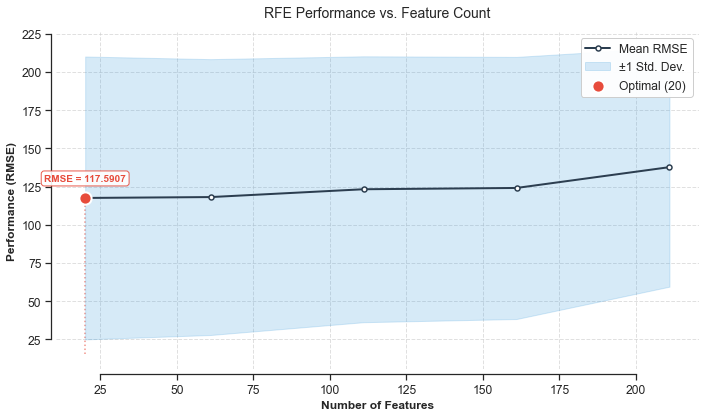

  Optimal Feature Set: 20 features
  Best RMSE: 117.5907
Selecting top 20 features for interaction generation out of 20 available.
Generating 190 interaction features from 20 features...

RFE feature selection: Round 2:


RFE Feature Selection:  25%|██▌       | 1/4 iteration

Iteration 0/4 | Features: 160 | RMSE: 96.1550 ± 73.6736 | Removed: [MACCS_114 X RDKit_VSA_EState5, MACCS_141 X MACCS_149, MACCS_141 X MACCS_150, MACCS_141 X MACCS_27, MACCS_141 X RDKit_BCUT2D_CHGHI, MACCS_141 X RDKit_BCUT2D_CHGLO, MACCS_141 X RDKit_BalabanJ, MACCS_141 X RDKit_EState_VSA5, MACCS_141 X RDKit_EState_VSA8, MACCS_141 X RDKit_FpDensityMorgan1, MACCS_141 X RDKit_MaxPartialCharge, MACCS_141 X RDKit_NumAliphaticRings, MACCS_141 X RDKit_VSA_EState5, MACCS_149 X MACCS_150, MACCS_149 X MACCS_27, MACCS_149 X RDKit_BCUT2D_CHGHI, MACCS_149 X RDKit_BCUT2D_CHGLO, MACCS_149 X RDKit_BalabanJ, MACCS_149 X RDKit_EState_VSA2, MACCS_149 X RDKit_EState_VSA5, MACCS_149 X RDKit_EState_VSA8, MACCS_149 X RDKit_FpDensityMorgan1, MACCS_149 X RDKit_MaxPartialCharge, MACCS_149 X RDKit_NumAliphaticRings, MACCS_149 X RDKit_SMR_VSA10, MACCS_149 X RDKit_VSA_EState5, MACCS_150 X MACCS_27, MACCS_150 X RDKit_BCUT2D_CHGHI, MACCS_150 X RDKit_BCUT2D_CHGLO, MACCS_150 X RDKit_BalabanJ, MACCS_150 X RDKit_EState_V

RFE Feature Selection: 100%|██████████| 4/4 iteration



Global best RMSE: 66.5853
Threshold (1.0% tolerance): 67.2512

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 20
  Selected RMSE: 66.5853
  Best features (Top 5): ['MACCS_114 X RDKit_MaxPartialCharge', 'MACCS_141 X RDKit_EState_VSA2', 'RDKit_BalabanJ', 'RDKit_EState_VSA8', 'MACCS_102 X RDKit_BalabanJ']



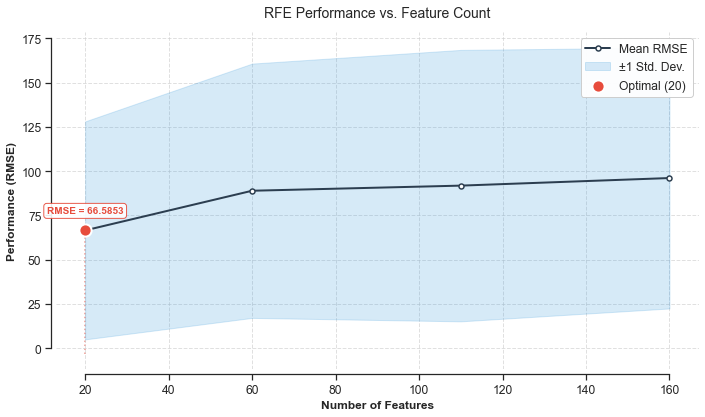

  Optimal Feature Set: 20 features
  Best RMSE: 66.5853


In [7]:
df_H_X_scaled, df_H_X_variance, RFE_results_bRo5_1, df_bRo5_X_RFE, RFE_results_bRo5_2, df_bRo5_X_final = feature_engineering_workflow('bRo5')

In [8]:
selected_features = hf.combine_features(df_Ro5_X_final, df_bRo5_X_final)

Number of features in Ro5 dataset: 60
Number of features in bRo5 dataset: 20
Number of overlapping features: 0
Overlapping features: set()
Total number of combined features: 80


In [9]:
with open(data_prefix + 'selected_feature_list.pkl', 'wb') as f:
    pickle.dump(selected_features, f)

In [10]:
with open(data_prefix + 'selected_feature_list.pkl', 'rb') as f:
    selected_features  = pickle.load(f)

print(selected_features)
print(len(selected_features))

['RDKit_BertzCT X RDKit_NHOHCount', 'RDKit_NumHeteroatoms X RDKit_NumRotatableBonds', 'RDKit_NumRotatableBonds X RDKit_fr_C_O_noCOO', 'RDKit_BertzCT X RDKit_fr_Ar_COO', 'MACCS_100 X RDKit_VSA_EState5', 'RDKit_BertzCT X RDKit_SlogP_VSA2', 'MACCS_126 X MACCS_131', 'RDKit_EState_VSA10 X RDKit_EState_VSA2', 'RDKit_EState_VSA2 X RDKit_RingCount', 'RDKit_RingCount X RDKit_fr_NH1', 'RDKit_NumRotatableBonds', 'RDKit_PEOE_VSA14 X RDKit_fr_methoxy', 'MACCS_131 X RDKit_fr_C_O_noCOO', 'MACCS_120 X RDKit_NumRotatableBonds', 'MACCS_120 X RDKit_TPSA', 'RDKit_PEOE_VSA14 X RDKit_SlogP_VSA2', 'MACCS_103 X MACCS_114', 'RDKit_NumHeteroatoms X RDKit_fr_C_O_noCOO', 'RDKit_EState_VSA2 X RDKit_fr_Ar_COO', 'MACCS_126 X RDKit_EState_VSA2', 'RDKit_EState_VSA2 X RDKit_fr_methoxy', 'MACCS_126 X RDKit_NHOHCount', 'MACCS_43 X RDKit_fr_Ar_COO', 'MACCS_126 X RDKit_VSA_EState8', 'MACCS_141 X RDKit_EState_VSA2', 'MACCS_103 X RDKit_SMR_VSA10', 'RDKit_SlogP_VSA2 X RDKit_fr_C_O_noCOO', 'RDKit_BCUT2D_CHGHI X RDKit_FpDensity

# Get the dataset

In [11]:
data_with_features = pd.read_parquet(data_prefix + 'data_with_all_features.parquet')

data_with_features

,MACCS_0,MACCS_1,MACCS_10,MACCS_100,MACCS_101,MACCS_102,MACCS_103,MACCS_104,MACCS_105,MACCS_106,...,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,Ro5,SMILES,Type
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0.346320,1,ON=Cc1cscc1,Train
1,0,0,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0.742933,1,O=C1CC[C@]2(C(=C1)CC[C@@H]1[C@@H]2[C@H](O)C[C@...,Train
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0.336491,1,[O-][n+]1ccccc1,Train
3,0,0,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0.470129,1,OC1CCC2(C(C1)CC=C1C2CCC2(C1CCC2C(CCC(C(C)C)C)C...,Train
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.635067,1,CC(=O)c1ccc(cc1)Br,Train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17215,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0.261785,1,c1ccc2c(c1)c1cc3ccc4c(c3nc1cc2)cccc4,Test
17216,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.730914,1,COc1cc(OC)cc(c1C#N)OC,Test
17217,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,7,0,0.596953,1,OCCCCCCCCCCc1ccccc1,Test
17218,0,0,0,0,1,0,1,0,1,0,...,0,0,0,0,0,0,0.439796,1,Clc1c2OC3Cc4c(C3Oc2c(c(c1Cl)Cl)Cl)cccc4,Test


In [12]:
df_final = hf.dataset_featurization(data_with_features, selected_features, data_prefix + 'final_dataset')

✓ RDKit: Added 208 features
✓ MACCS: Added 167 features
Generating 70125 interaction features from 375 features...
../data_curation/processed_data/final_dataset dataset saved.


In [13]:
df_final = pd.read_parquet(data_prefix + 'final_dataset.parquet')

In [14]:
df_final_scaled = hf.standardize_data(df_final, data_prefix + 'df_final_scaler.pkl')

Number of feature columns to standardize: 80
Scaler saved to ../data_curation/processed_data/df_final_scaler.pkl
